**1. Importamos la librerias de python para manipular y analizar datos**

In [38]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as mat
import seaborn as sea

**2. Creamos un DataFrame del origen d elos datos en este caso un archivo delimitado por comas**

este comando perimte cargar en memoria cache(temporal), los datos que se van a analizar estan utilizando las librerias de panda que nos permite la manipulacion de datos 

In [39]:
df=pd.read_csv('UberDataset.csv')


**3. Omprimimos en pantalla los datos para verificar la carga completas**

**IMPORTANTE** la impresion de los datos del DATAFRAME no da contexto importante como el numnro de filas, el numero de columnas y en el caso de los datos **cuantitativos** una suma de total de las columnas, en caso de los casos **cualitativos** nos colocara en texto NaN (Not As Number) por defecto no s epuede sumar  

In [40]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**4. leer los datos de una columna especifica**

el uso de **[Columna]** nos permite poder acceder a los datos de la columna del DataFrame, mostrando los 5 primeros y 5 ultimos el total de registro y el tipo de datos cabe mencionar que este comando 

In [41]:
df['PURPOSE']

0        Meal/Entertain
1                   NaN
2       Errand/Supplies
3               Meeting
4        Customer Visit
             ...       
1151     Temporary Site
1152            Meeting
1153     Temporary Site
1154     Temporary Site
1155                NaN
Name: PURPOSE, Length: 1156, dtype: object

**5. Manipulamos los dtaos cargados para obtener el total de cada valor registrado en la columna**

El metodo value.counts()es una funcion preprogramada de python que nos permite agrupar los registro por sus valores y obtener el total de cada valor detectado 

In [42]:
df['PURPOSE'].value_counts()

PURPOSE
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Charity ($)          1
Commute              1
Name: count, dtype: int64

**6. Aplicamos las mismas funcion con otra columna**

en este caso vemos que tipo de viajes hizo el conductor, resultado **Business** (Negocios) o **'Personal'** (Autos personales)

In [43]:
df['CATEGORY'].value_counts()

CATEGORY
Business    1078
Personal      77
Name: count, dtype: int64

**Limpiamos el resgistro de los viajes que no tinen un localizacion de inicio**

In [44]:
df=df[df['START']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**7. LIMPIAMOS LOS REGISTROS DE LOS VIAJES QUE NO SON LOCALIZABLES**

para este analisis es importante limpiar los datos de la muestra que nos sirve para para nuestro analisis, empezamos por eliminar los registros (filas), de aquellos viajes que no registraron un destino localizable, para ello y utilizamos el comando logico de no igualdad (!=) para filtrar el dataframe, esto nos arroja a un resultado de boloeano "true" para los que tiene un destino localizable "false" para los que no.

In [45]:
df['STOP']!='Unknown Location'

0        True
1        True
2        True
3        True
4        True
        ...  
1150     True
1151    False
1153     True
1154     True
1155     True
Name: STOP, Length: 1008, dtype: bool

**8. Eliminamos del DataFrame los registros  que contengan false**

In [46]:
df[df['STOP']!='Unknown Location']

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**9. sobreescribimos el DataFrame (df)** 

para eliminar de nuestro analisis es decir que que el docimento de origen de los datos(csv) sigue sin cambios, asignamos el resu

In [47]:
df=df[df['STOP']!='Unknown Location']

**10. Volvemos a imprimir el dataframe** 

En este resultado en este resultado podemos observar que el numero datframe cuanta con solo 1007 filas a diferencias del original que tenia 1156 es  decir se eliminaron 149 registros que no tenian un destino localizable.

In [48]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**11. Repetimos el proceso de limpieza ahora para los viajes que no tienen un origen localizable (SMART)**

en este caso hacemos toda la limpieza en una sola operacion, para el analisis de datos reduciendo de **1007** a **945** registros, incluyendo que hay **62** viajes que tuvieron un destino (STOP) pero no unorigen (START)

In [49]:
df=df[df['START']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [50]:
def value(val):
    val=str(val)
    return val.replace('?','a')
df['START']=df['START'].apply(value)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**12. Conceptos de repaso**

12.1 Funciones o metodos en python
una funcion o metodo en bloque de codigo reutilizable que realiza una tarea especial, sirve para evitar repetir instruccioes y organizar mejor los programas 
En el lenguaje de programacion de python las funciones son declarada con la palabra recervada **def**, y para ejecutarla basta con escribir el nombre que se le asigno a la misma,el uso de 0 es para evitar los datos de entrada en caso de que sen necesarios:

definicion 

In [51]:
def saludar():
    print(" hola, Binevenido a python paras le analisis de datos")

llamada

In [52]:
saludar()

 hola, Binevenido a python paras le analisis de datos


12.2 funnciones que reciben un parametro o datos de entrada. En algunas ocaciones es necesario enviar datos para la ejecucion del metodo, para ello debemos declalarlo en la funcion entr () 

Definicion

In [53]:
def saludar_nombre(nombre):
    return f"hola, {nombre}, Bienvenido a python para el analisis de datos"
    

llamada:

In [ ]:
saludar_nombre("Yul")

'hola, GERA, Bienvenido a python para el analisis de datos'

In [ ]:
saludar_nombre("Extraño")

'hola, Mari, Bienvenido a python para el analisis de datos'

12.3. fuinciones dque manda a llamar otras funciones y regresan el resultado en un procedimiento , en este caso utilizaremos una funcion prefdefinida llamamdaq en python denominada replace que nos permite sistituir letras en una cadena de texto 

In [56]:
def sustituir_vocales(texto):
    texto = texto.replace("A","4")
    texto = texto.replace("a","4")

    texto = texto.replace("E","3")
    texto = texto.replace("e","3")

    texto = texto.replace("I","1")
    texto = texto.replace("i","1")

    texto = texto.replace("O","0")
    texto = texto.replace("o","0")

    texto = texto.replace("U","∪")
    texto = texto.replace("u","∪")

    return texto


llamado:

In [ ]:
print(sustituir_vocales(saludar_nombre("Yuleni")))

h0l4, G3r4rd0, B13nv3n1d0 4 pyth0n p4r4 3l 4n4l1s1s d3 d4t0s


**13.Limpiesa de letras ilegibles**

Ejecutramos el proceso de susititucion de letras ilegibles (para este caso de estudiosolo hay letras a con tilde que se cargaron con un ?, y se limpia con una "a" para mejor compresion del analisis 

In [58]:
df ['START'] = df['START'].astype(str).str.replace('?', 'a')
df ['STOP'] = df['STOP'].astype(str).str.replace('?', 'a')
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**14. Rellenar datso vacios por un valor generico asignado**

durante el proceso de limpieza y trasfomacion de los datos, existe la posibilidad de corregir los datos que no se encuentran registrad, para este caso usaremos na funcion de **pandas** llamadas *filina*  (sirve para rellenar los datos no disponibles(not avaliable)

In [59]:
df['PURPOSE'].fillna('Other',inplace=True)
df

C:\Users\PC-22\AppData\Local\Temp\ipykernel_9628\2789362272.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PURPOSE'].fillna('Other',inplace=True)


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Other
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**15.Medidas de tendencia central**

una vez terminada la fase de limpieza de datos, comenzamoscon la estadistica basica en este caso consultaremos las medidas de tendencia central siendo: total, media, moda, cuatilla y desviacion estandar, maximo, y minimo.

Utilizamos un metodo **describe**- de nuestro dataframe, se buscaron todos los cuantitativos(numeors) de la muestra y realizara el calculo de estos valores, para eso tenemos, la columna **miles*, la cual hace referencia al total de millas terrestre (1.69 km) recorrimos porel conducto en un servicio de viaje a traves de uber 

In [60]:
df.describe()

,MILES
count,945.000000
mean,22.809841
std,397.276813
min,0.500000
25%,2.600000
50%,5.300000
75%,9.900000
max,12204.700000


para el caso de la mediana y moda, estas debe ser calculadas por separadas a traves de las funciones .mode y .median

In [61]:
print(df['MILES'].mode())

0    9.9
Name: MILES, dtype: float64


In [62]:
print(df['MILES'].median())

5.3


en **Coclusion** este dataframe nos permite analizar un pequeño muestra de **945** viajesw realizados a traves de la aplicacion de uber, determinando que la distancia minima registrada es .5 millas y la maxima es de 12204.700000 millas cn un promedio de 22.8 millas, siendo  la distancia repetida de **9.9** millas y la mediana de **5.3** millas

**16. Limpieza de datos: segmentar fchas de viajes, ignorando la HH.MM.SS**

In [63]:
def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-','/')
df['START_DATE']=df['START_DATE'].apply(val)
df

def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-','/')
df['END_DATE']=df['END_DATE'].apply(val)
df

df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01/06/2016,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016,12/31/2016,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**17. Eliminamos la ultima fila de totoles**

La ultima fila de totales no es necesaria para la grafica dadoq ue podria generar error en la presentacion de datos, por ello la eliminamos de DataFRame  usando el comando drop y el nuero de la piosicion de la fila ,elimar encerrada entre corchetes

In [64]:
df.drop([1155], inplace=True)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01/06/2016,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016,Business,Katunayake,Gampaha,6.4,Temporary Site


18. **Este procedimiento se realiza para limpiar el conjunto de datos eliminando valores atípicos (outliers) de la columna MILES.**

*Obtener el percentil 95 de la columna MILES*
*Esto sirve para identificar el límite superior de valores normales*

a = df['MILES'].quantile(0.95)

*Obtener el percentil 5 de la columna MILES*
*Esto sirve para identificar el límite inferior de valores normales*

b = df['MILES'].quantile(0.05)

*Filtrar los datos mayores al percentil 5*
*Así eliminamos valores demasiado pequeños (outliers inferiores)*

df3 = df[df['MILES'] > b]

*Filtrar los datos menores al percentil 95*
*Así eliminamos valores demasiado grandes (outliers superiores)*

df3 = df3[df3['MILES'] < a]

*Mostrar el nuevo DataFrame filtrado*

df3

In [65]:
a=df['MILES'].quantile(0.95)
b=df['MILES'].quantile(0.05)
df3=df[df['MILES']>b]
df3=df[df['MILES']<a]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting


**19. Cálculo de desviacion estandar**

para entender que tan variables odispersas son las distancia de los viajes

In [66]:
df3['STD']=df.MILES.std()
df3

C:\Users\PC-22\AppData\Local\Temp\ipykernel_9628\672307851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['STD']=df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other,21.472805
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805
...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805


**20.Estimar el valor de z-score o puntuacion z**

Con la finalidad de estimar la dispercion de los datos, es decir que tan variados o diferente son , utilizamos esta formula para poder continuar con el analisis  EDA (Exploratory Dat Analisys).

In [67]:
df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()
df3

C:\Users\PC-22\AppData\Local\Temp\ipykernel_9628\2738585948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other,21.472805,-0.228442
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


**21 filtramos aquello que no estan en el rango de -1 y 1**

In [68]:
df['MILES'].describe()

count    944.000000
mean       9.905297
std       21.472805
min        0.500000
25%        2.600000
50%        5.300000
75%        9.900000
max      310.300000
Name: MILES, dtype: float64

In [69]:
df3['MILES'].describe()

count    896.000000
mean       6.344196
std        4.849186
min        0.500000
25%        2.500000
50%        4.900000
75%        9.025000
max       25.600000
Name: MILES, dtype: float64

In [70]:
df3=df3[(df3.Z>-1) & (df3.Z<1)]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01/01/2016,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,5.0,Other,21.472805,-0.228442
2,01/02/2016,01/02/2016,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01/05/2016,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01/06/2016,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


22. **Gráfica Básica para un Análisis 

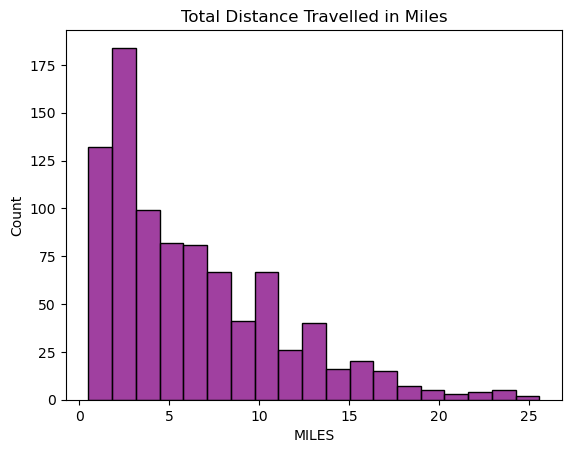

In [73]:
mat.title('Total Distance Travelled in Miles')
sea.histplot(df3.MILES,color='Purple')
mat.show()

23. **Gráfico de Clasificación de  Viajes por Ctaegoría**



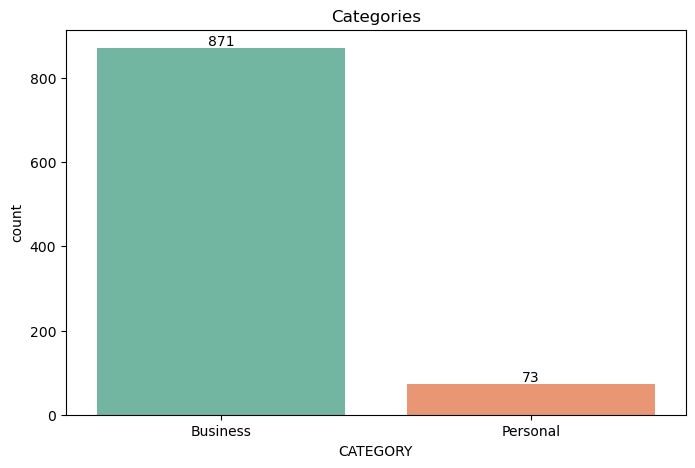

In [80]:
import matplotlib.pyplot as plt
import seaborn as sea

fig, ax = plt.subplots(figsize=(8,5))

grafica = sea.countplot(
    data=df,
    x='CATEGORY',
    hue='CATEGORY',
    palette='Set2',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Categories')

# Agregar etiquetas con totales
for container in ax.containers:
    ax.bar_label(container)

plt.show()

24. **Gráfica de Viaje por Propósito (Purpose)**

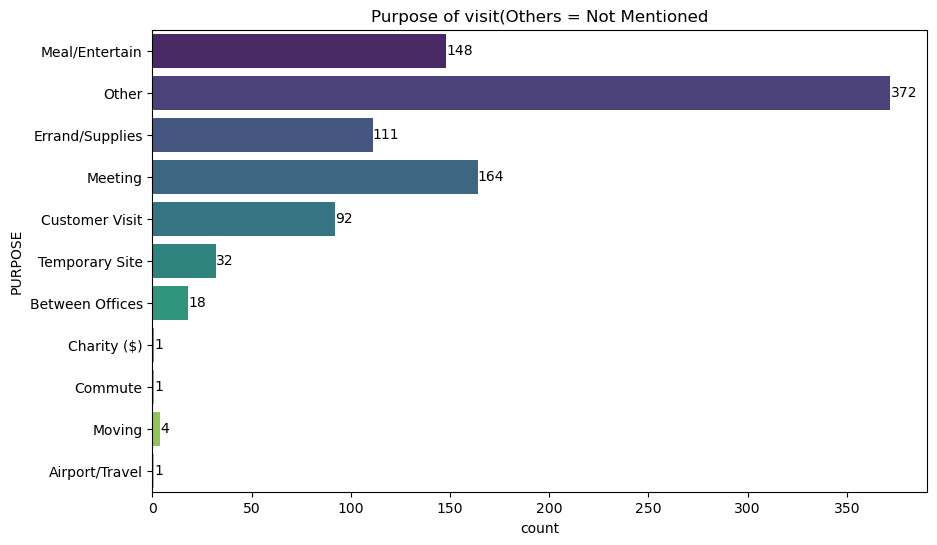

In [84]:
fig, ax = mat.subplots(figsize=(10,6))

grafica = sea.countplot(
    data=df,
    y='PURPOSE',
    hue='PURPOSE',
    palette='viridis',
    legend=False,
)

# Título
ax.set_title('Purpose of visit(Others = Not Mentioned')

# Agregar etiquetas con totales
for container in ax.containers:
    ax.bar_label(container)
mat.show()

25. **

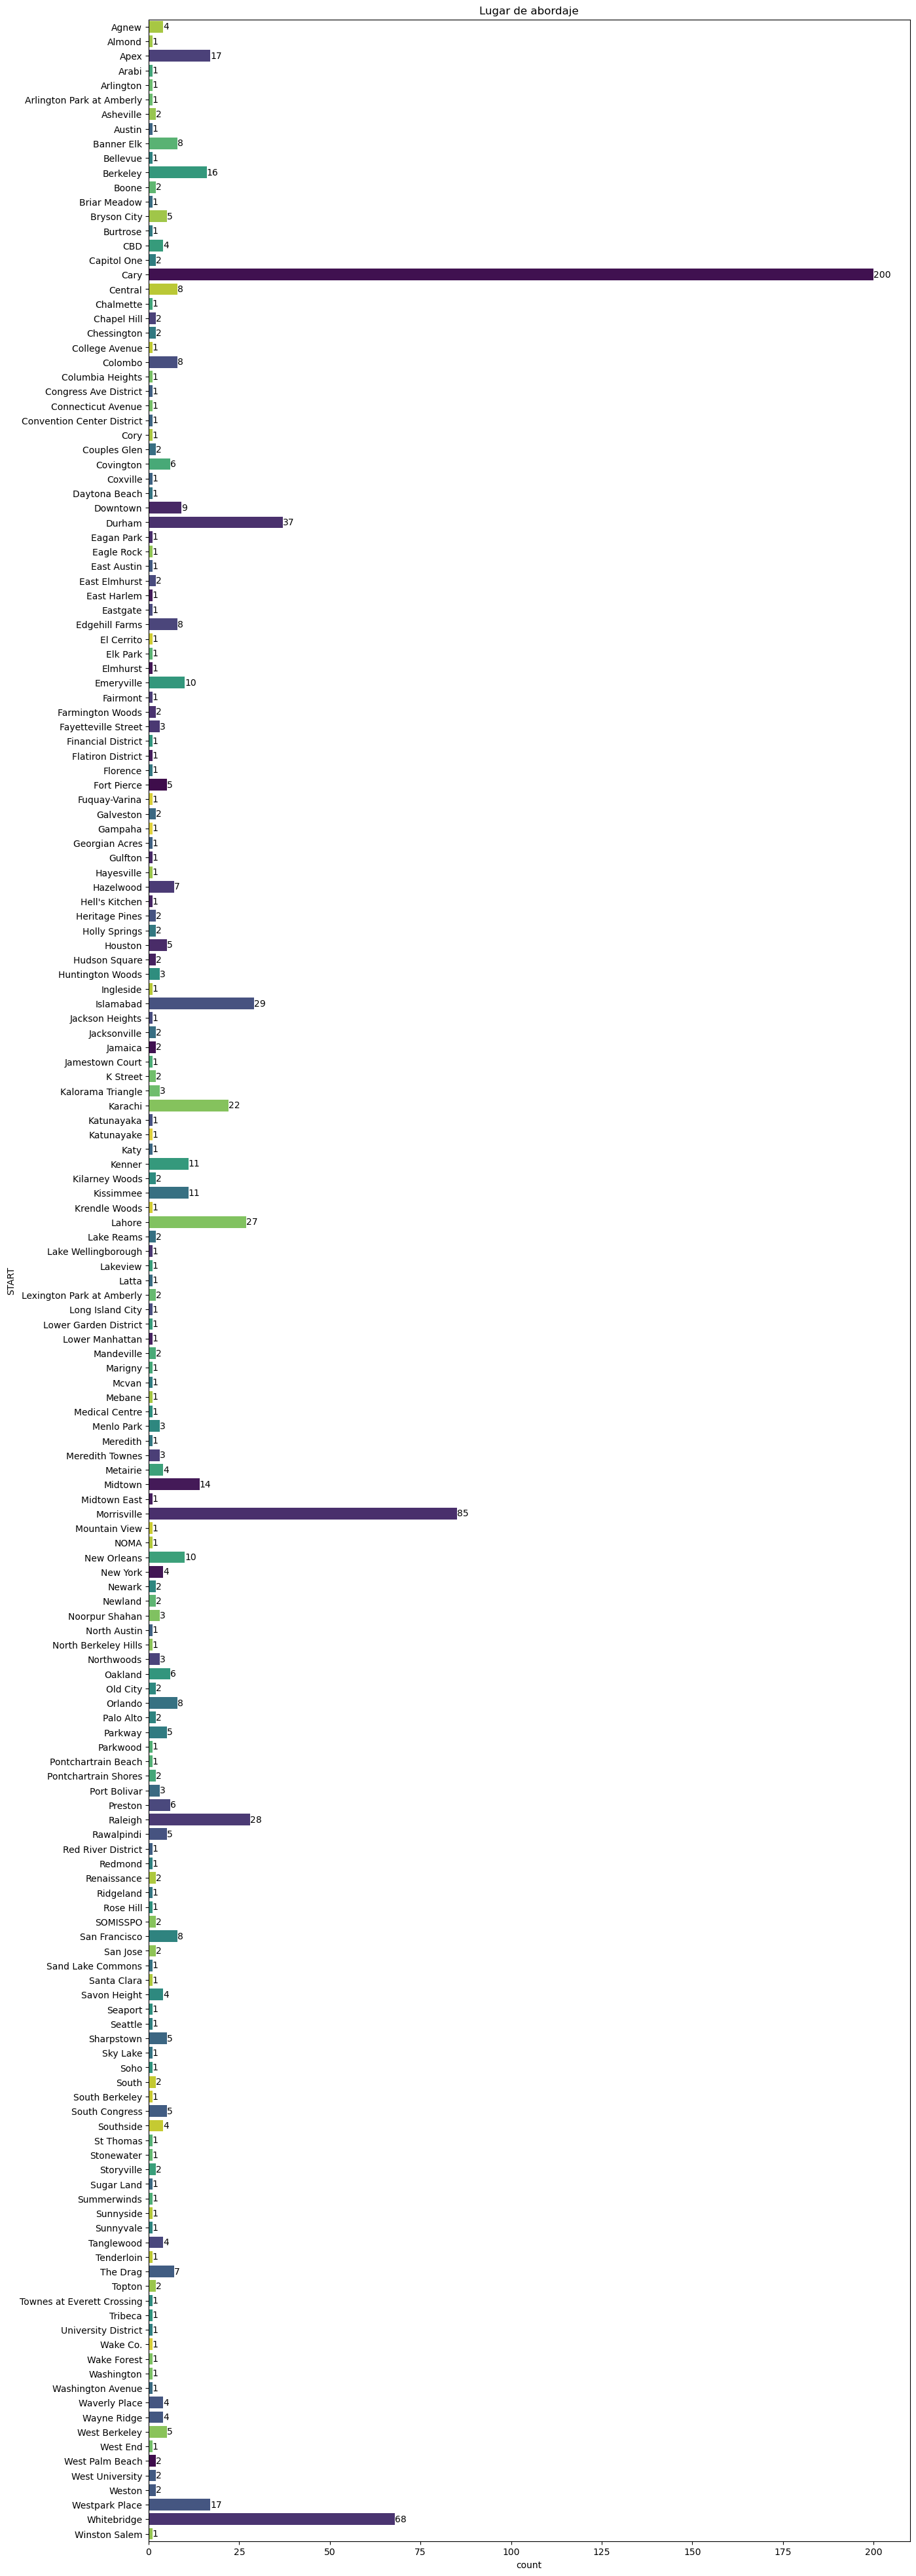

In [89]:
fig, ax = mat.subplots(figsize=(15,50))

orden = sorted(df['START'].dropna().unique())

grafica = sea.countplot(
    data=df,
    y='START',
    order=orden,
    hue='START',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)

ax.set_title('Lugar de abordaje')

for container in ax.containers:
    ax.bar_label(container)

mat.show()
    

16. **Gráfica de llegada (STROP)**

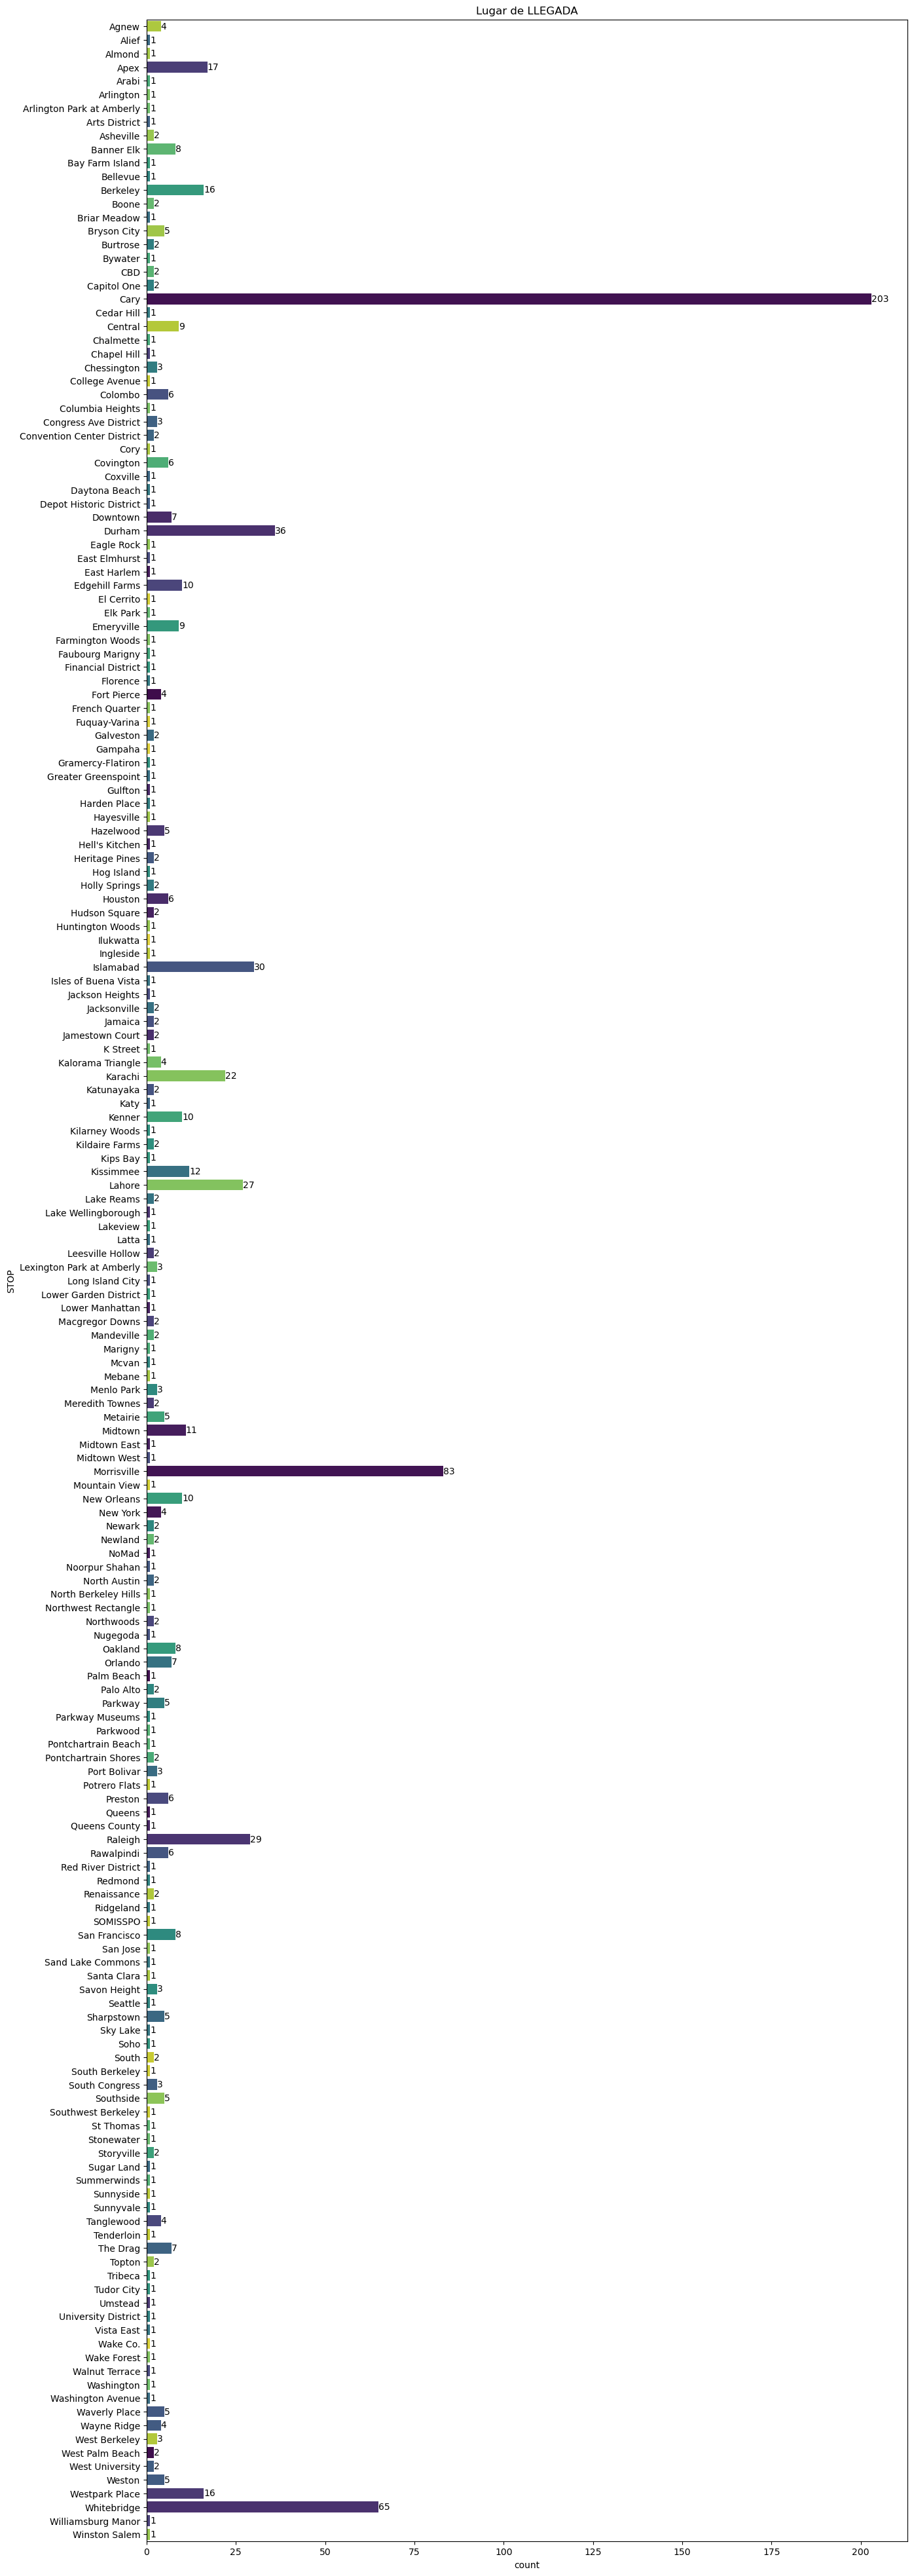

In [92]:
fig, ax = mat.subplots(figsize=(15,50))

orden = sorted(df['STOP'].dropna().unique())

sea.countplot(
    data=df,
    y='STOP',
    order=orden,
    hue='STOP',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)

ax.set_title('Lugar de LLEGADA')

for container in ax.containers:
    ax.bar_label(container)

mat.show()